In [1]:
import segmentation_models_pytorch as smp
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split
from torch import nn
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision.transforms import functional as TF, InterpolationMode

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
preprocessing_fn = smp.encoders.get_preprocessing_fn("resnet34", "imagenet")
preprocessing_fn # To find the resnet34 mean and std on imagenet

functools.partial(<function preprocess_input at 0x77c95a2e73d0>, input_space='RGB', input_range=[0, 1], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [4]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_names = None, split_file = None, transform = None):
        
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform #optinal augmentations
        if (image_names is None) == (split_file is None):
            raise ValueError("Provide exactly one of image_names or split_file.")
            
        if split_file is not None:
            with open(split_file, 'r') as f:
                self.images = [line.strip().split()[0] + '.jpg' for line in f]
        else:
            self.images = [name + '.jpg' for name in image_names]
            
        self.image_transform = transforms.Compose([transforms.Resize((256,256)),
                                                   transforms.ToTensor(),
                                                   transforms.Normalize(
                                                       mean = [0.485, 0.456, 0.406],
                                                       std=[0.229, 0.224, 0.225]
                                                   )
                                                  ])
                                                       
        self.mask_transform = transforms.Compose([transforms.Resize((256,256),
                                                interpolation=Image.NEAREST)])
    
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self,idx):
        image_name = self.images[idx]
        image_path = os.path.join(self.image_dir, image_name)
        
        mask_name = image_name.replace('.jpg','.png')
        mask_path = os.path.join(self.mask_dir, mask_name)
    
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)
    
    
        image = self.image_transform(image)
        mask = self.mask_transform(mask)
    
        mask = np.array(mask)

        mask = (mask == 1).astype(np.int64)
        mask = torch.tensor(mask)
        
        return image, mask

In [5]:
class SegmentationTransform:
    def __call__(self, image, mask):
        if random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
             # we garantee that both image and mask receive the same transformation
        if random.random() < 0.5:
            angle = random.uniform(-15,15)
            translate = (int(random.uniform(-0.1, 0.1) * image.width), int(random.uniform(-0.1, 0.1) * image.height))
            scale = random.uniform(0.9, 1.1)

            image = TF.affine(image, angle, translate, scale, shear = 0, interpolation=InterpolationMode.BILINEAR)
            mask = TF.affine(mask, angle, translate, scale, shear = 0, interpolation = InterpolationMode.NEAREST)

        if random.random() < 0.5:
            brightness = random.uniform(0.8, 1.2)
            image = TF.adjust_brightness(image, brightness) #Apply the brightness only to the image, not the mask.
        if random.random() < 0.5:
            contrast = random.uniform(0.8, 1.2)
            image = TF.adjust_contrast(image, contrast)
        if random.random() < 0.5:
            saturation = random.uniform(0.8, 1.2)
            image = TF.adjust_saturation(image, saturation)
        
        return image, mask

In [6]:
image_dir = 'Dataset/images'
mask_dir = 'Dataset/annotations/trimaps'

In [7]:
with open('Dataset/annotations/trainval.txt','r') as f:
    image_names = [line.strip().split()[0] for line in  f]

In [8]:
train_names, val_names = train_test_split(image_names, test_size = 0.15, random_state=42, shuffle=True)

In [9]:
train_transform = SegmentationTransform()

In [10]:
train_dataset = SegmentationDataset(image_dir=image_dir, mask_dir=mask_dir, image_names=train_names, transform=train_transform)

In [11]:
val_dataset = SegmentationDataset(image_dir, mask_dir, val_names)

In [12]:
test_dataset = SegmentationDataset(image_dir, mask_dir, split_file='Dataset/annotations/test.txt')

In [13]:
print(f'Train: {len(train_dataset)}')
print(f'Validation: {len(val_dataset)}')
print(f'Test: {len(test_dataset)}')

Train: 3128
Validation: 552
Test: 3669


In [14]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle = True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle= False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

In [15]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, outputs, masks):

        probs = torch.softmax(outputs, dim=1)
        pet_probs = probs[:, 1, :, :]

        masks = masks.float()

        # Calculate Dice separately for each image
        intersection = (pet_probs * masks).sum(dim=(1, 2))

        dice = (2 * intersection + self.smooth ) / (
            pet_probs.sum(dim=(1, 2)) +
            masks.sum(dim=(1, 2)) +
            self.smooth
        )

        # Average Dice across the batch
        dice = dice.mean()

        return 1 - dice

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):

        pred = F.softmax(pred, dim=1)
        pred = pred[:, 1]   # pet channel

        target = target.float()

        intersection = (pred * target).sum()

        dice = (
            2. * intersection + self.smooth
        ) / (
            pred.sum() + target.sum() + self.smooth
        )

        return 1 - dice

In [27]:
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5], device=device))
        self.dice = DiceLoss()

    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        dice_loss = self.dice(pred, target)

        return ce_loss + dice_loss

In [17]:
def dice_score(preds, masks):

    preds = (preds == 1).float()
    masks = (masks == 1).float()

    intersection = (preds * masks).sum()

    dice = (2 * intersection) / (
        preds.sum() + masks.sum() + 1e-8
    )

    return dice

In [18]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            preds = torch.argmax(outputs, dim=1)

            dice = dice_score(preds, masks)

            running_loss += loss.item()
            running_dice += dice.item()

    return (
        running_loss / len(loader),
        running_dice / len(loader)
    )

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0

    progress_bar = tqdm(loader, desc="Training")


    for images, masks in progress_bar:

        images = images.to(device)
        masks = masks.to(device)


        outputs = model(images)

        loss = criterion(outputs, masks)


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    return running_loss / len(loader)

In [20]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device, best_dice=0.0, best_epoch=0, initial_epoch = 0, counter = 0):
    patience = 7

    for epoch in range(initial_epoch, epochs):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_dice = validate(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(val_dice)
        lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Dice: {val_dice:.4f} | "
            f"LR: {lr:.6f}"
        )

        if val_dice > best_dice:
            best_dice = val_dice
            best_epoch = epoch + 1
            counter = 0

            torch.save(model.state_dict(), "best_unet_resnet34.pth")
            print("Best model saved!")

        else:
            counter += 1
            print(f"No improvement: {counter}/{patience}")

            if counter >= patience:
                print("Early stopping!")
                break

        print(f"Best Dice: {best_dice:.4f} at epoch {best_epoch}\n")

    return best_dice, best_epoch

In [21]:
model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels = 3 ,classes = 2)
model = model.to(device)

### Freeze the encoder and train at lr=1e-4 for 10 epochs initially

In [22]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [23]:
for name, param in model.encoder.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer2.2.conv1.weight False
layer2.2.bn1.weight False
layer2.2.bn1

In [24]:
criterion = CombinedLoss()
optimizer = torch.optim.Adam([
    {"params": model.decoder.parameters(), "lr":1e-4},
    {"params": model.segmentation_head.parameters(), "lr":1e-4}
 ])

In [25]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode = "max",
    factor = 0.1,
    patience=3
)

In [26]:
for name, param in model.encoder.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer2.2.conv1.weight
layer2.2.bn1.weight
layer2.2.bn1.bias
layer2.2.conv2.weight
layer2.2.bn2.weight
layer2.2.bn2.bias
layer2.3.conv1.weight
layer2.3.bn1.weight
layer2.3.bn1.bias
layer2.3.conv2.weight
layer2.3.bn2.weight
layer2.3.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight


In [28]:
best_dice, best_epoch = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=10,
    device=device
)
print(f"\nTraining finished!")
print(f"Best Dice: {best_dice:.4f}")
print(f"Best Epoch: {best_epoch}")

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:20<00:00,  2.45it/s, loss=0.3968]


Epoch 1/10 | Train Loss: 0.5635 | Val Loss: 0.3165 | Dice: 0.9124 | LR: 0.000100
Best model saved!
Best Dice: 0.9124 at epoch 1



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.77it/s, loss=0.3024]


Epoch 2/10 | Train Loss: 0.3050 | Val Loss: 0.2518 | Dice: 0.9235 | LR: 0.000100
Best model saved!
Best Dice: 0.9235 at epoch 2



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:13<00:00,  2.66it/s, loss=0.2666]


...

Epoch 8/10 | Train Loss: 0.1946 | Val Loss: 0.1933 | Dice: 0.9379 | LR: 0.000100
Best model saved!
Best Dice: 0.9379 at epoch 8



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:13<00:00,  2.68it/s, loss=0.1876]


Epoch 9/10 | Train Loss: 0.1881 | Val Loss: 0.1961 | Dice: 0.9368 | LR: 0.000100
No improvement: 1/7
Best Dice: 0.9379 at epoch 8



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:13<00:00,  2.68it/s, loss=0.1715]


Epoch 10/10 | Train Loss: 0.1836 | Val Loss: 0.1952 | Dice: 0.9368 | LR: 0.000100
No improvement: 2/7
Best Dice: 0.9379 at epoch 8


Training finished!
Best Dice: 0.9379
Best Epoch: 8


### Unfreeze the encoder and train the whole network, encoder at lr=1e-5, decoder and head at lr=1e-4

In [29]:
for param in model.encoder.parameters():
    param.requires_grad = True

In [30]:
for name, param in model.encoder.named_parameters():
    print(name, param.requires_grad)

conv1.weight True
bn1.weight True
bn1.bias True
layer1.0.conv1.weight True
layer1.0.bn1.weight True
layer1.0.bn1.bias True
layer1.0.conv2.weight True
layer1.0.bn2.weight True
layer1.0.bn2.bias True
layer1.1.conv1.weight True
layer1.1.bn1.weight True
layer1.1.bn1.bias True
layer1.1.conv2.weight True
layer1.1.bn2.weight True
layer1.1.bn2.bias True
layer1.2.conv1.weight True
layer1.2.bn1.weight True
layer1.2.bn1.bias True
layer1.2.conv2.weight True
layer1.2.bn2.weight True
layer1.2.bn2.bias True
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.downsample.0.weight True
layer2.0.downsample.1.weight True
layer2.0.downsample.1.bias True
layer2.1.conv1.weight True
layer2.1.bn1.weight True
layer2.1.bn1.bias True
layer2.1.conv2.weight True
layer2.1.bn2.weight True
layer2.1.bn2.bias True
layer2.2.conv1.weight True
layer2.2.bn1.weight True
layer2.2.bn1.bias True
layer2.2.conv2.weight True


In [31]:
optimizer = torch.optim.Adam([
    {"params": model.encoder.parameters(), "lr": 1e-5},
    {"params": model.decoder.parameters(), "lr":1e-4},
    {"params": model.segmentation_head.parameters(), "lr":1e-4},
])

In [32]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode = "max",
    factor = 0.1,
    min_lr= 1e-6,
    patience=3
)

In [33]:
best_dice, best_epoch = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=30,
    device=device,
    best_dice=best_dice,
    best_epoch=best_epoch,
    initial_epoch=10,

)
print(f"\nTraining finished!")
print(f"Best Dice: {best_dice:.4f}")
print(f"Best Epoch: {best_epoch}")

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:22<00:00,  2.38it/s, loss=0.1877]


Epoch 11/30 | Train Loss: 0.1821 | Val Loss: 0.1903 | Dice: 0.9383 | LR: 0.000010
Best model saved!
Best Dice: 0.9383 at epoch 11



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:21<00:00,  2.40it/s, loss=0.1949]


Epoch 12/30 | Train Loss: 0.1730 | Val Loss: 0.1835 | Dice: 0.9397 | LR: 0.000010
Best model saved!
Best Dice: 0.9397 at epoch 12



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:22<00:00,  2.37it/s, loss=0.1760]


...

Epoch 28/30 | Train Loss: 0.1197 | Val Loss: 0.1727 | Dice: 0.9453 | LR: 0.000001
Best model saved!
Best Dice: 0.9453 at epoch 28



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:22<00:00,  2.38it/s, loss=0.1099]


Epoch 29/30 | Train Loss: 0.1180 | Val Loss: 0.1738 | Dice: 0.9449 | LR: 0.000001
No improvement: 1/7
Best Dice: 0.9453 at epoch 28



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:21<00:00,  2.41it/s, loss=0.1187]


Epoch 30/30 | Train Loss: 0.1176 | Val Loss: 0.1719 | Dice: 0.9454 | LR: 0.000001
Best model saved!
Best Dice: 0.9454 at epoch 30


Training finished!
Best Dice: 0.9454
Best Epoch: 30


In [34]:
best_dice, best_epoch = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=40,
    device=device,
    best_dice=best_dice,
    best_epoch=best_epoch,
    initial_epoch=30,

)
print(f"\nTraining finished!")
print(f"Best Dice: {best_dice:.4f}")
print(f"Best Epoch: {best_epoch}")

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:20<00:00,  2.44it/s, loss=0.1324]


Epoch 31/40 | Train Loss: 0.1167 | Val Loss: 0.1726 | Dice: 0.9453 | LR: 0.000001
No improvement: 1/7
Best Dice: 0.9454 at epoch 30



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:21<00:00,  2.41it/s, loss=0.1025]


Epoch 32/40 | Train Loss: 0.1163 | Val Loss: 0.1717 | Dice: 0.9453 | LR: 0.000001
No improvement: 2/7
Best Dice: 0.9454 at epoch 30



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:20<00:00,  2.45it/s, loss=0.1093]


...

Epoch 38/40 | Train Loss: 0.1136 | Val Loss: 0.1709 | Dice: 0.9459 | LR: 0.000001
No improvement: 2/7
Best Dice: 0.9459 at epoch 36



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:20<00:00,  2.42it/s, loss=0.1433]


Epoch 39/40 | Train Loss: 0.1140 | Val Loss: 0.1725 | Dice: 0.9453 | LR: 0.000001
No improvement: 3/7
Best Dice: 0.9459 at epoch 36



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:21<00:00,  2.40it/s, loss=0.1533]


Epoch 40/40 | Train Loss: 0.1139 | Val Loss: 0.1731 | Dice: 0.9453 | LR: 0.000001
No improvement: 4/7
Best Dice: 0.9459 at epoch 36


Training finished!
Best Dice: 0.9459
Best Epoch: 36


### Evaluation

In [35]:
best_model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels = 3 ,classes = 2).to(device)
best_model.load_state_dict(torch.load("best_unet_resnet34.pth"))
best_model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05,

In [36]:
test_loss, test_dice = validate(best_model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")

Test Loss: 0.1972
Test Dice: 0.9408


In [38]:
def predict_image(img_path, model, device):
    img_rgb = Image.open(img_path).convert("RGB")
    transform = transforms.Compose([transforms.Resize((256,256)),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean = preprocessing_fn.keywords['mean'], std = preprocessing_fn.keywords['std'])
                                   ])
    x = transform(img_rgb)
    x = x.unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(x)
        pred = torch.argmax(output, dim = 1)
        
    img_rgb = transforms.Resize((256, 256))(img_rgb)
    
    plt.figure(figsize = (10, 8))
    plt.subplot(1,2,1)
    plt.imshow(img_rgb)
    plt.title('Image')

    plt.subplot(1,2,2)
    plt.imshow(pred.squeeze(0).cpu(), cmap = 'gray')
    plt.title('Predicted Mask')
    plt.show()

### Testing on some internet images

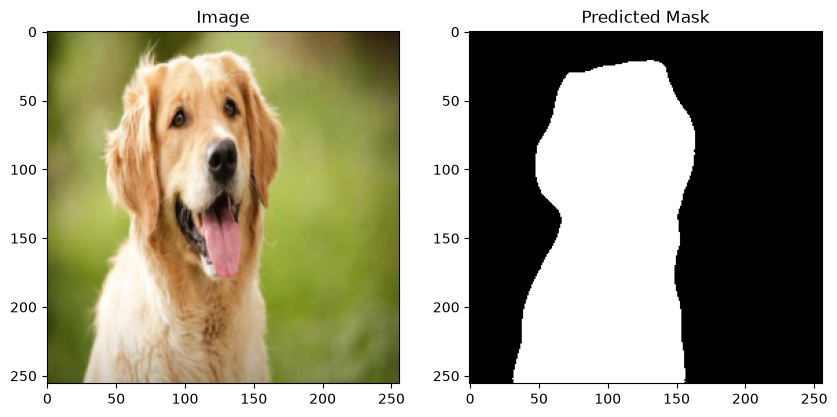

In [39]:
predict_image('dog.jpg', best_model, device)

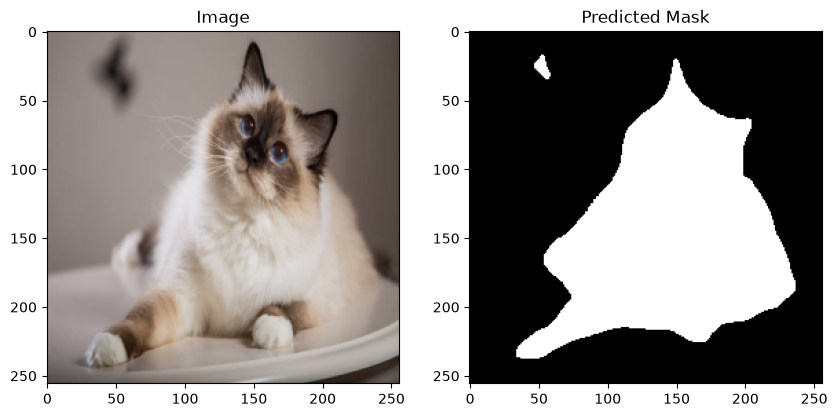

In [40]:
predict_image('cat.jpg', best_model, device)

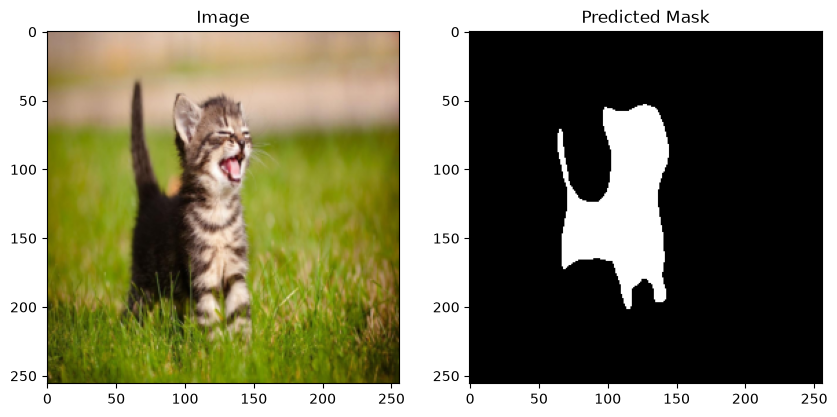

In [41]:
predict_image('kitten.jpg', best_model, device)

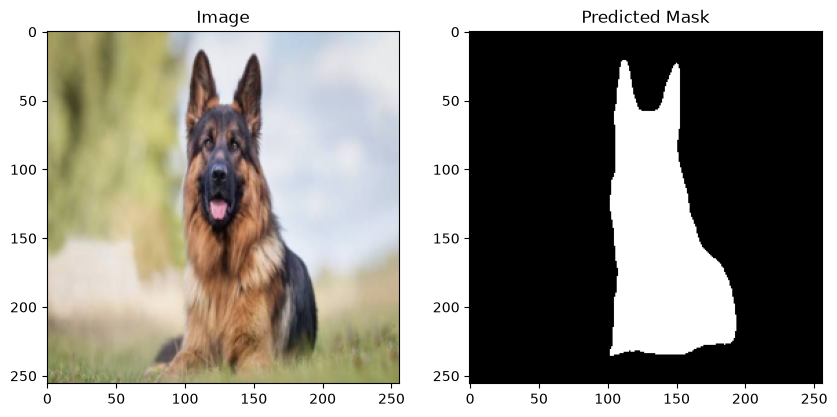

In [42]:
predict_image('dog8.jpg', best_model, device)

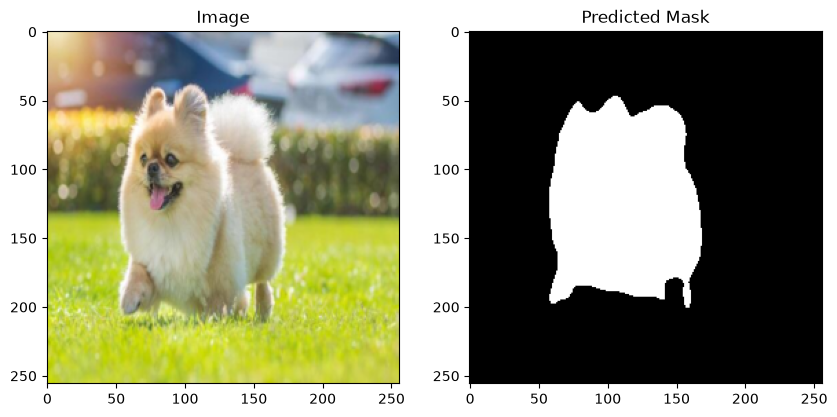

In [43]:
predict_image('dog9.jpg', best_model, device)

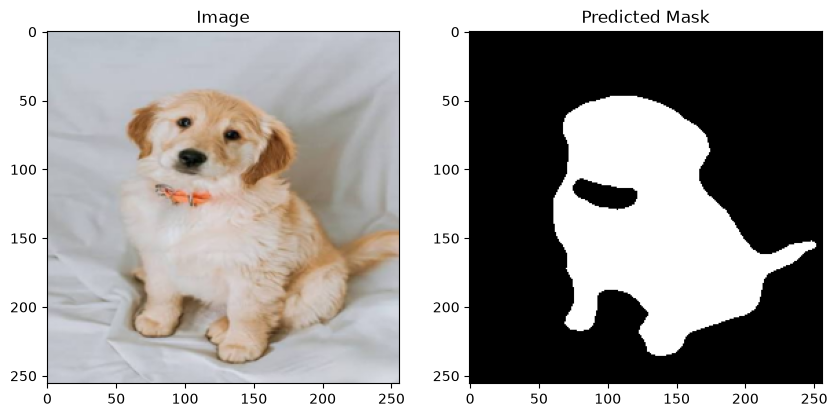

In [44]:
predict_image('dog2.jpg', best_model, device)

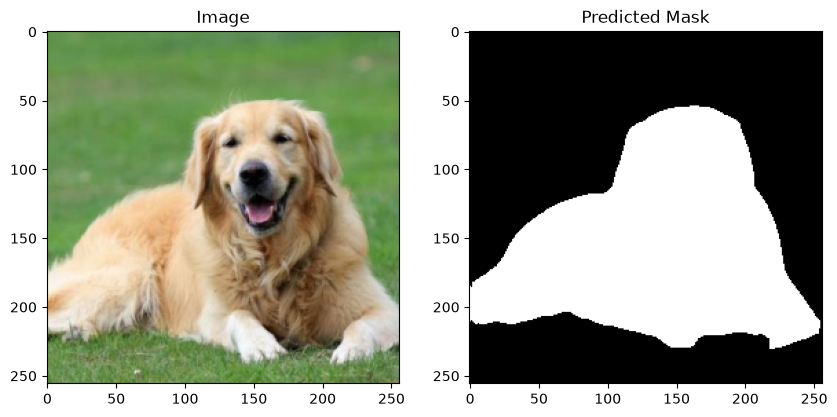

In [45]:
predict_image('dog3.jpg', best_model, device)

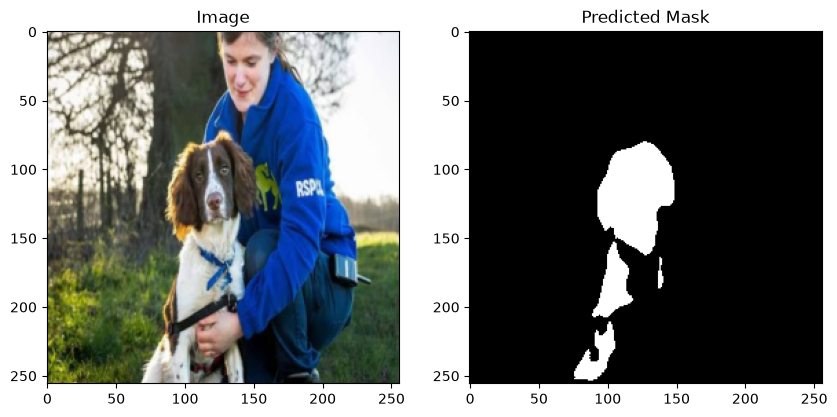

In [47]:
predict_image('dog6.jpg', best_model, device)

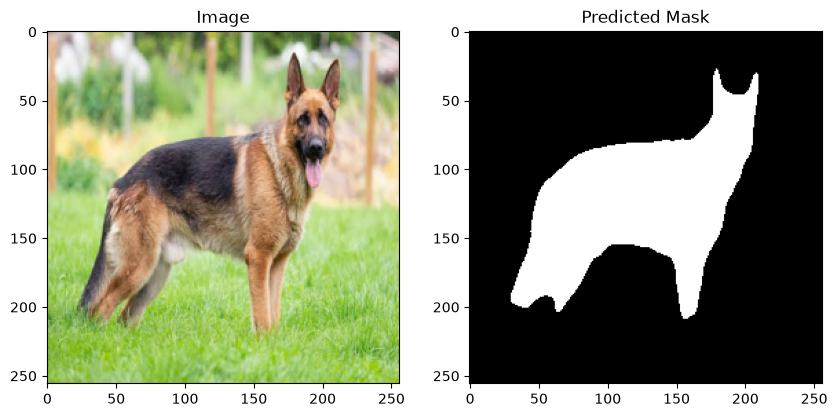

In [48]:
predict_image('dog7.jpg', best_model, device)

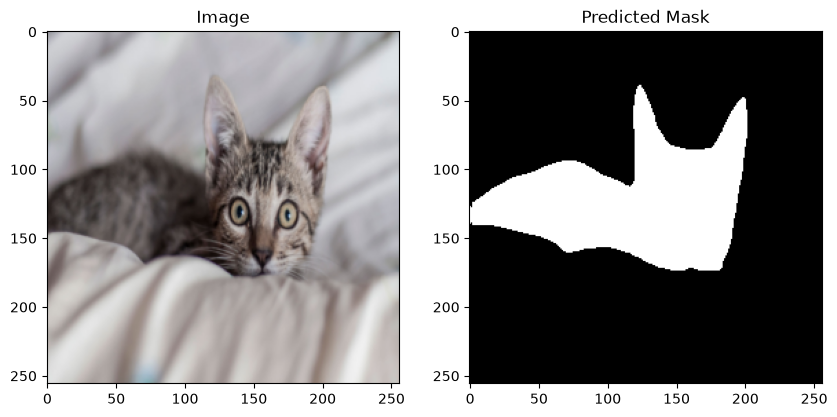

In [60]:
predict_image('cat2.jpg', best_model, device)

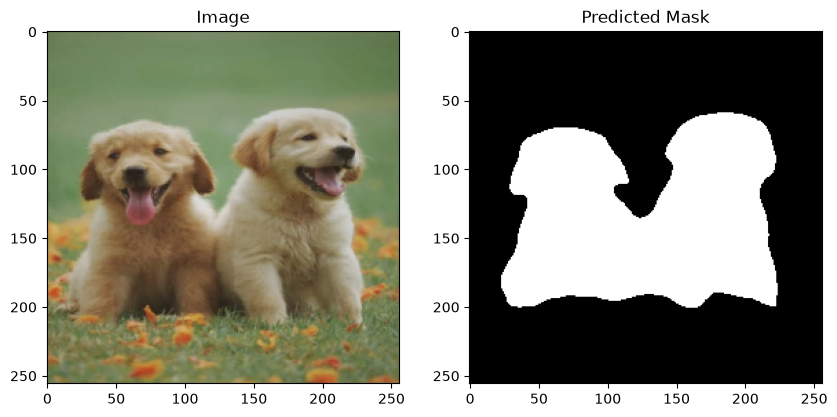

In [66]:
predict_image('dog5.jpeg', best_model, device)

### Visualize some test data

In [61]:
best_model.eval()

images, masks = next(iter(test_loader))

with torch.no_grad():
    outputs = best_model(images.to(device))
    preds = torch.argmax(outputs, dim=1).cpu()

In [62]:
def denormalize(img, mean, std):
    mean = torch.tensor(mean, device = img.device).view(3,1,1)
    std = torch.tensor(std, device = img.device).view(3,1,1)
    img = img * std + mean
    img = torch.clamp(img, 0,1)
    return img

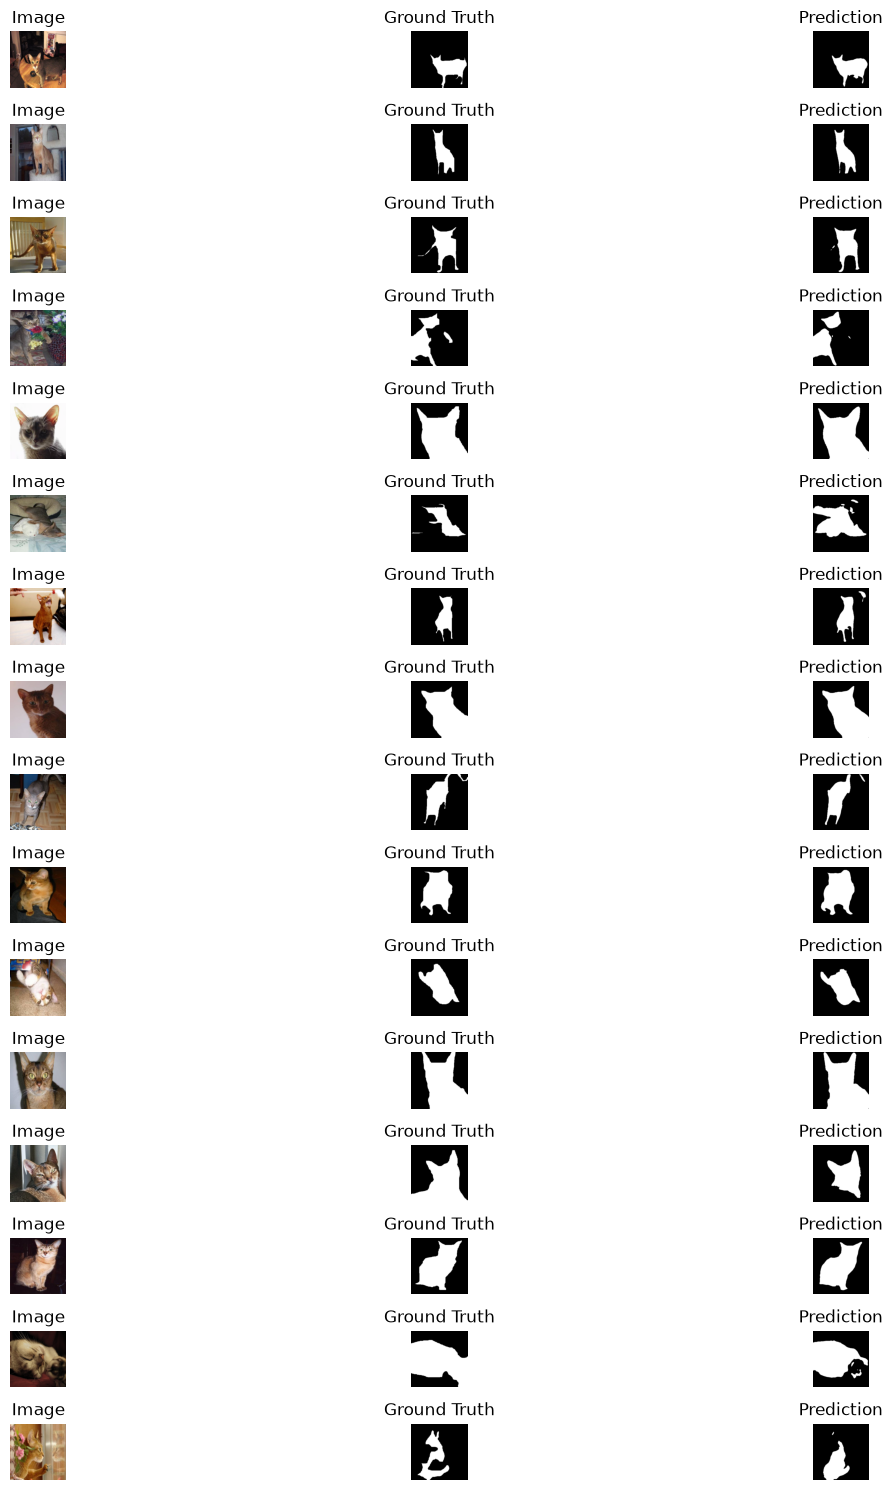

In [63]:
fig, axes = plt.subplots(16, 3, figsize=(15, 15))

for row, i in enumerate(range(0, 16)):

    img = denormalize(images[i], mean=preprocessing_fn.keywords['mean'], std=preprocessing_fn.keywords['std'])

    axes[row, 0].imshow(img.permute(1,2,0))
    axes[row, 0].set_title("Image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(masks[i], cmap="gray")
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(preds[i], cmap="gray")
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

#### More evaluation with torchmetrics

In [53]:
from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryPrecision, BinaryConfusionMatrix, BinaryRecall, BinaryJaccardIndex

In [54]:
def evaluate_model(model, device, loader):

    iou_metric = BinaryJaccardIndex().to(device)
    f1_metric = BinaryF1Score().to(device)
    precision_metric = BinaryPrecision().to(device)
    recall_metric = BinaryRecall().to(device)

    model.eval()

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device).long()

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Convert to binary PET masks
            preds_pet = preds == 1
            masks_pet = masks == 1

            # PET metrics
            iou_metric.update(preds_pet, masks_pet)
            f1_metric.update(preds_pet, masks_pet)
            precision_metric.update(preds_pet, masks_pet)
            recall_metric.update(preds_pet, masks_pet)

    iou = iou_metric.compute()
    f1 = f1_metric.compute()
    precision = precision_metric.compute()
    recall = recall_metric.compute()

    return {
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
    }

In [55]:
print(evaluate_model(best_model, device, test_loader))

{'iou': 0.8911503553390503, 'precision': 0.9313707947731018, 'recall': 0.9537808299064636, 'f1': 0.9424425959587097}
